## Download Dataset from Kaggle

In [1]:
#!/bin/bash
!kaggle datasets download bhavikjikadara/dog-and-cat-classification-dataset -p /home/midori/Desktop/Nural_Network/Data

Dataset URL: https://www.kaggle.com/datasets/bhavikjikadara/dog-and-cat-classification-dataset
License(s): apache-2.0
100%|████████████████████████████████████████| 775M/775M [05:39<00:00, 2.40MB/s]



In [3]:
from zipfile import ZipFile
from pathlib import Path

zip_dir = "/home/midori/Desktop/Nural_Network/Data/dog-and-cat-classification-dataset.zip"
extract_dir = "/home/midori/Desktop/Nural_Network/Data/dog_cat_dataset"

with ZipFile(zip_dir,'r') as zip_ref:
    zip_ref.extractall(extract_dir)
print(f"file extracted to: {extract_dir}")

file extracted to: /home/midori/Desktop/Nural_Network/Data/dog_cat_dataset


## source

In [36]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Flatten,Input
from tensorflow.keras.applications.vgg16 import VGG16 # pretrained on ImageNet

import numpy as np
import matplotlib.pyplot as plt

In [63]:
conv_base = VGG16(
    weights='imagenet',
    include_top = False, # remove the fully connected classifier
    input_shape=(150,150,3) # 150*150 RGB image
)

In [ ]:
conv_base.summary()

# (None, 150, 150, 64)

# None → batch size (dynamic)
# 150 x 150 → spatial dimensions
# 64 → number of filters (channels) each filter is 3*3 kernel

# 1,792
# Conv layer params = (kernel_h × kernel_w × input_channels + bias) × filters
# kernel_h = 3
# kernel_w = 3

# so conv_layer_params_block1_conv1 = (3*3*3 + 1)*64 = 1,792

# block1_conv2 = (3*3*64 + 1)*64 = 36,928

# Conv2D(filters = F, kernel = K×K, input_channels = C)
# (K × K × C + 1) × F

# filters == Features
# previous filter == input channel for the currect conv_block

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [64]:
model = Sequential([
    conv_base,
    Flatten(),
    Dense(256, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [65]:
conv_base.trainable = False # we are freezing the convolution layers trainable parameters

In [6]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,812,353 (64.13 MB)

 Trainable params: 2,097,665 (8.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [47]:
train_ds = keras.utils.image_dataset_from_directory(
    directory='../../Data/PetImages/',
    validation_split=0.2,
    subset='training',
    seed=42,
    labels='inferred',
    label_mode='int',  # output label 0 or 1
    batch_size=32,     # shape becomes (32, 150, 150, 3) returns 32 images at once
    image_size=(150,150)
)

validation_ds = keras.utils.image_dataset_from_directory(
    directory='../../Data/PetImages/',
    validation_split=0.2,
    subset='validation',
    seed=42,
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(150,150)
)

#  labels='inferred'
#  Cat → label 0
#  Dog → label 1 (assigned automatically)

# images, labels = next(iter(train_ds))
# loads images in batch of 32 images

Found 24824 files belonging to 2 classes.
Using 19860 files for training.
Found 24824 files belonging to 2 classes.
Using 4964 files for validation.


In [48]:
from collections import Counter
from pathlib import Path

def split_counts(ds):
    return Counter(Path(p).parent.name for p in ds.file_paths)

print("Train split:", split_counts(train_ds))
print("Val split:", split_counts(validation_ds))

Train split: Counter({'Cat': 9978, 'Dog': 9882})
Val split: Counter({'Dog': 2515, 'Cat': 2449})


In [8]:
for images, labels in train_ds.take(1):
    print(images.shape, labels.shape)

(32, 150, 150, 3) (32,)


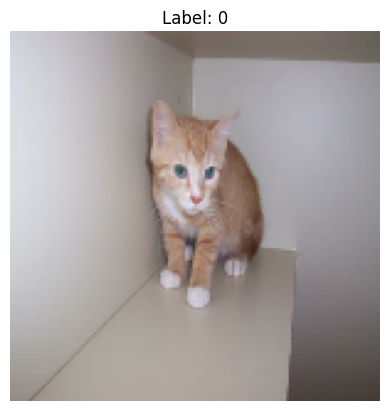

In [27]:
for images, labels in train_ds.take(1): # take one random batch not one image
    img = images[0].numpy().astype("uint8")   # take first image from that choosen batch
    label = labels[0]

    plt.imshow(img)
    plt.title(f"Label: {label}")
    plt.axis("off")
    plt.show()

In [66]:
# normalize each images 
def process(image,label):
    image = tf.cast(image/255., tf.float32)
    return image,label

In [67]:
train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [68]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [69]:
train_ds = train_ds.take(50)
validation_ds = validation_ds.take(50)

In [70]:
history = model.fit(train_ds, epochs=5, validation_data=validation_ds)

Epoch 1/5
34/50 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.4715 - loss: 1.2569

Corrupt JPEG data: 1403 extraneous bytes before marker 0xd9


50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4753 - loss: 1.1470

Corrupt JPEG data: 162 extraneous bytes before marker 0xd9


50/50 ━━━━━━━━━━━━━━━━━━━━ 185s 4s/step - accuracy: 0.4888 - loss: 0.8827 - val_accuracy: 0.5169 - val_loss: 0.7010
Epoch 2/5
31/50 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.5210 - loss: 0.7144

...

50/50 ━━━━━━━━━━━━━━━━━━━━ 190s 4s/step - accuracy: 0.5000 - loss: 0.7028 - val_accuracy: 0.5169 - val_loss: 0.6958
Epoch 4/5
36/50 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.5001 - loss: 0.6996

Corrupt JPEG data: 1403 extraneous bytes before marker 0xd9


50/50 ━━━━━━━━━━━━━━━━━━━━ 176s 4s/step - accuracy: 0.5125 - loss: 0.6997 - val_accuracy: 0.5381 - val_loss: 0.6925
Epoch 5/5
39/50 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.5042 - loss: 0.7058

Corrupt JPEG data: 1403 extraneous bytes before marker 0xd9


50/50 ━━━━━━━━━━━━━━━━━━━━ 172s 3s/step - accuracy: 0.4956 - loss: 0.7067 - val_accuracy: 0.5169 - val_loss: 0.7073


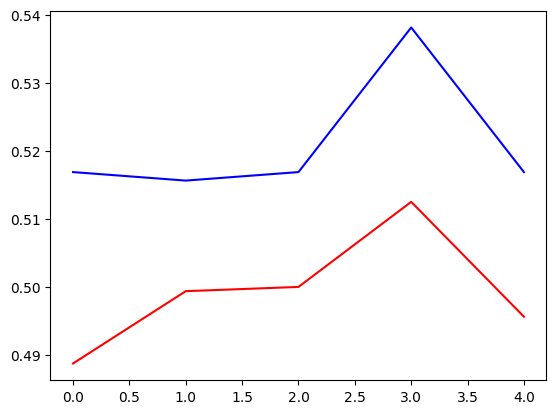

In [71]:
plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')

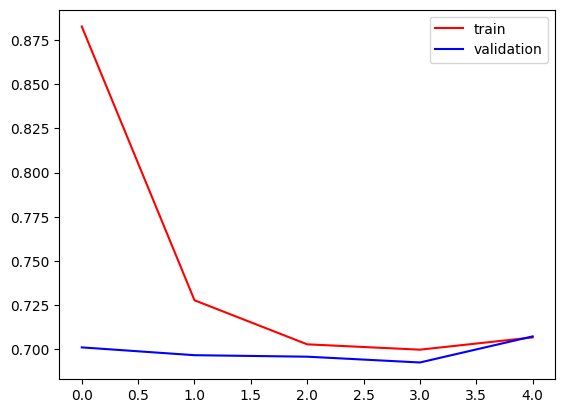

In [72]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()